In [ ]:
!pip install python-docx PyPDF2 pandas scikit-learn nltk matplotlib seaborn wordcloud openpyxl

In [ ]:
!pip install streamlit

In [ ]:
#Imports and constants
import os
import re
from collections import Counter
import pandas as pd
import numpy as np
import docx
from PyPDF2 import PdfReader
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import streamlit as st
import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

st.title("File Upload")
st.file_uploader('Upload your Resume', type = ['docx'])

# Path to folder with your uploaded files (this notebook assumes uploads were saved to /mnt/data/)
from google.colab import drive
drive.mount('/content/drive')
DATA_FOLDER = "/content/drive/MyDrive/Resumes"
OUTPUT_FOLDER = "./output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

STOPWORDS = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-03-08 06:42:13.864 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 06:42:14.334 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-08 06:42:14.335 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 06:42:14.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 06:42:14.338 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 06:42:14.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 06:42:14.340 Thread 'MainThread': missing S

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#File reading utilities
# docx reader
def extract_text_docx(path):
    try:
        doc = docx.Document(path)
        return "\n".join([p.text for p in doc.paragraphs])
    except Exception as e:
        return ""

# pdf reader
def extract_text_pdf(path):
    try:
        reader = PdfReader(path)
        text = ""
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
        return text
    except Exception as e:
        return ""

# generic wrapper
def extract_text_from_file(path):
    low = path.lower()
    if low.endswith(".docx"):
        return extract_text_docx(path)
    if low.endswith(".pdf"):
        return extract_text_pdf(path)
    # .doc older binary files often not reliably readable - skip or convert externally
    if low.endswith(".doc"):
        # best-effort: try docx if file actually docx with wrong extension; else skip
        try:
            return extract_text_docx(path)
        except:
            return ""
    # otherwise return empty
    return ""


In [ ]:
#Build dataset by iterating files in DATA_FOLDER
from google.colab import drive
 # Correcting the path to the data folder

rows = []
files = sorted([f for f in os.listdir(DATA_FOLDER) if f.lower().endswith(('.docx', '.doc', '.pdf'))])

print(f"Found {len(files)} candidate files in {DATA_FOLDER} (showing first 20):")
print(files[:20])

for fname in files:
    fpath = os.path.join(DATA_FOLDER, fname)
    text = extract_text_from_file(fpath)
    if not text or len(text.strip()) < 20:
        # skip very small / empty extractions
        print("Skipped (empty or unreadable):", fname)
        continue
    rows.append({"filename": fname, 'C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx': fpath, "text": text})

df = pd.DataFrame(rows)
print("Extracted text from files:", df.shape)
df.head(3)


Found 79 candidate files in /content/drive/MyDrive/Resumes (showing first 20):
['Anil kumar.docx', 'AradhanaTripathi[4_0].docx', 'Buddha Vamsi.docx', 'ChinnaSubbarayuduM_Hexaware.docx', 'Gopi Krishna_Hexaware.docx', 'Hari Krishna M_Hexaware.doc', 'Harikrishna Akula_Hexaware.doc', 'Hima Mendu_Hexaware.doc', 'Himaja G_(Hexaware).docx', 'Internship_Ravali_Musquare Technologies (1).docx', 'Internship_Susovan Bag_Musquare Technologies.docx', 'J. Sumanth Royal_Hexaware.doc', 'Jyotiverma_Heaware.docx', 'Madeeswar A_Hexaware.doc', 'MooraboyinaGuravaiah_Hexaware.docx', 'Naresh Babu Cherukuri_Hexaware.doc', 'Nazeer Basha.doc', 'Neeraj Mishra.docx', 'P V Sai Krishna_ Hexaware.docx', 'PSyamKumar[2_3].docx']
Skipped (empty or unreadable): Hari Krishna M_Hexaware.doc
Skipped (empty or unreadable): Harikrishna Akula_Hexaware.doc
Skipped (empty or unreadable): Hima Mendu_Hexaware.doc
Skipped (empty or unreadable): J. Sumanth Royal_Hexaware.doc
Skipped (empty or unreadable): Madeeswar A_Hexaware.doc
Sk

,filename,C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx,text
0,Anil kumar.docx,/content/drive/MyDrive/Resumes/Anil kumar.docx,ANIL KUMAR MADDUKURI \t\t\nSQL & MSBI Develop...
1,AradhanaTripathi[4_0].docx,/content/drive/MyDrive/Resumes/AradhanaTripath...,\nAradhana Tripathi\n\nCurrent Location: Gachi...
2,Buddha Vamsi.docx,/content/drive/MyDrive/Resumes/Buddha Vamsi.docx,BUDDHA VAMSI ...


In [ ]:
#Basic cleaning helpers and auto-label function
def basic_clean(text):
    text = str(text)
    # normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def text_to_lower_onlyalpha(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def assign_label_auto(text):
    t = text.lower()
    # priority order - tune keywords as necessary
    if any(k in t for k in ["react", "redux", "frontend", "javascript", "mui", "reactjs"]):
        return "React Developer"
    if any(k in t for k in ["ssis", "ssrs", "t-sql", "msbi", "etl", "power bi", "powerbi", "sql developer", "pl/sql", "oracle sql"]):
        return "SQL Developer"
    if any(k in t for k in ["workday", "eib", "studio", "core connector", "picof", "peci", "workday studio"]):
        return "Workday Consultant"
    if any(k in t for k in ["peoplesoft", "peoplecode", "application engine", "ps query", "fscm", "hcm", "component interface", "app engine"]):
        return "PeopleSoft Consultant"
    if any(k in t for k in ["test cases", "manual testing", "stlc", "sdlc", "qa", "tester"]):
        return "Manual Tester"
    return "Other"


In [ ]:
# Create dataframe columns: raw, cleaned, tokenized, label
df['text_raw'] = df['text'].apply(basic_clean)
df['text_alpha'] = df['text_raw'].apply(text_to_lower_onlyalpha)
df['word_count'] = df['text_alpha'].apply(lambda x: len(x.split()))
df['label_auto'] = df['text_raw'].apply(assign_label_auto)
df['extension'] = df['filename'].apply(lambda x: x.split(".")[-1].lower())

# show summary
df[['filename','extension','word_count','label_auto']].sort_values('word_count', ascending=False).head(10)
df


,filename,C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx,text,text_raw,text_alpha,word_count,label_auto,extension
0,Anil kumar.docx,/content/drive/MyDrive/Resumes/Anil kumar.docx,ANIL KUMAR MADDUKURI \t\t\nSQL & MSBI Develop...,ANIL KUMAR MADDUKURI SQL & MSBI Developer Summ...,anil kumar maddukuri sql msbi developer summar...,617,SQL Developer,docx
1,AradhanaTripathi[4_0].docx,/content/drive/MyDrive/Resumes/AradhanaTripath...,\nAradhana Tripathi\n\nCurrent Location: Gachi...,Aradhana Tripathi Current Location: Gachibowli...,aradhana tripathi current location gachibowli ...,700,SQL Developer,docx
2,Buddha Vamsi.docx,/content/drive/MyDrive/Resumes/Buddha Vamsi.docx,BUDDHA VAMSI ...,BUDDHA VAMSI CAREER OBJECTIVE: Have 2.11 years...,buddha vamsi career objective have years of it...,210,SQL Developer,docx
3,ChinnaSubbarayuduM_Hexaware.docx,/content/drive/MyDrive/Resumes/ChinnaSubbarayu...,Chinna Subbarayudu M\nDOB: 06th March 1994\nNa...,Chinna Subbarayudu M DOB: 06th March 1994 Nati...,chinna subbarayudu m dob th march nationality ...,816,SQL Developer,docx
4,Gopi Krishna_Hexaware.docx,/content/drive/MyDrive/Resumes/Gopi Krishna_He...,\t\n\n\nName : Gopi Krishna Reddy\n\t\...,Name : Gopi Krishna Reddy PROFESSIONAL SUMMERY...,name gopi krishna reddy professional summery w...,555,Workday Consultant,docx
5,Himaja G_(Hexaware).docx,/content/drive/MyDrive/Resumes/Himaja G_(Hexaw...,\n ...,G Himaja Career Objective To work towards achi...,g himaja career objective to work towards achi...,614,Workday Consultant,docx
6,Internship_Ravali_Musquare Technologies (1).docx,/content/drive/MyDrive/Resumes/Internship_Rava...,Name: Ravali P \n\n ...,Name: Ravali P Curriculum Vitae Specialization...,name ravali p curriculum vitae specialization ...,291,Workday Consultant,docx
7,Internship_Susovan Bag_Musquare Technologies.docx,/content/drive/MyDrive/Resumes/Internship_Suso...,\nSUSOVAN BAG \nSeeking a challenging ...,SUSOVAN BAG Seeking a challenging position in ...,susovan bag seeking a challenging position in ...,181,React Developer,docx
8,Jyotiverma_Heaware.docx,/content/drive/MyDrive/Resumes/Jyotiverma_Heaw...,\n\nJYOTI VERMA\t\t\t\t\t\n\n\n\n3 years of Ex...,JYOTI VERMA 3 years of Experience in Workday a...,jyoti verma years of experience in workday as ...,461,Workday Consultant,docx
9,MooraboyinaGuravaiah_Hexaware.docx,/content/drive/MyDrive/Resumes/MooraboyinaGura...,\n\nMooraboyina Guravaiah\nWorkday Integration...,Mooraboyina Guravaiah Workday Integration Spec...,mooraboyina guravaiah workday integration spec...,889,Workday Consultant,docx


In [ ]:
#Save initial dataset CSV (backup)
df.to_csv(os.path.join(OUTPUT_FOLDER, "raw_resume_dataset.csv"), index=False)
print("Saved raw dataset to:", os.path.join(OUTPUT_FOLDER, "raw_resume_dataset.csv"))


Saved raw dataset to: ./output/raw_resume_dataset.csv


In [ ]:
# EDA - overview and missing checks
print("Total resumes:", len(df))
print("\nCounts by auto label:\n", df['label_auto'].value_counts())

# missing values
print("\nMissing counts per column:\n", df.isnull().sum())


Total resumes: 53

Counts by auto label:
 label_auto
SQL Developer            20
React Developer          20
Workday Consultant       11
PeopleSoft Consultant     2
Name: count, dtype: int64

Missing counts per column:
 filename                                                           0
C:/Users/ysant/Downloads/P608-Dataset/P608-Dataset/Resumes_Docx    0
text                                                               0
text_raw                                                           0
text_alpha                                                         0
word_count                                                         0
label_auto                                                         0
extension                                                          0
dtype: int64


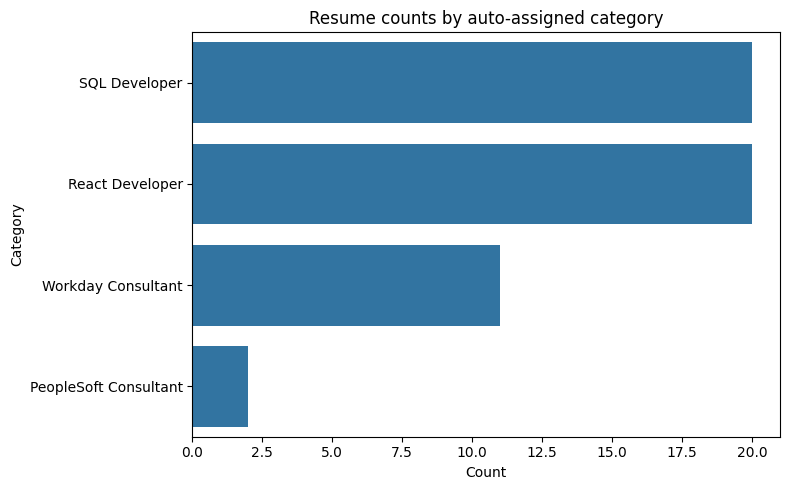

In [ ]:
#Visual: category distribution
plt.figure(figsize=(8,5))
sns.countplot(y='label_auto', data=df, order=df['label_auto'].value_counts().index)
plt.title("Resume counts by auto-assigned category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


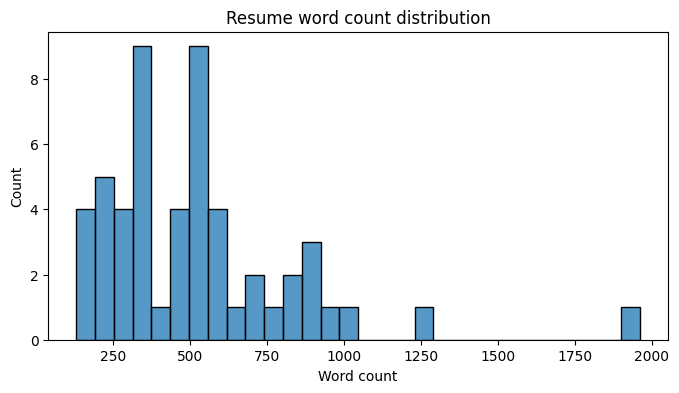

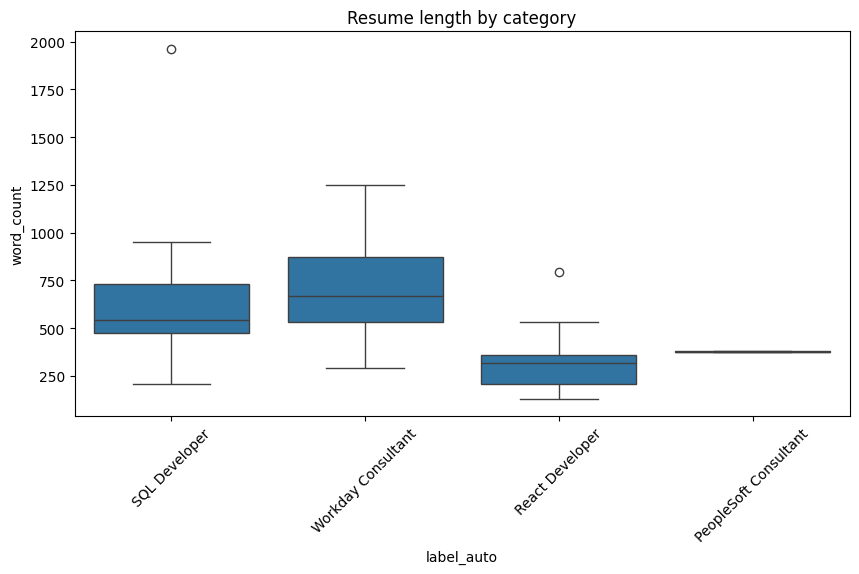

In [ ]:
#Resume length distribution
plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=30, kde=False)
plt.title("Resume word count distribution")
plt.xlabel("Word count")
plt.show()

# boxplot by category
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='label_auto', y='word_count')
plt.xticks(rotation=45)
plt.title("Resume length by category")
plt.show()


In [ ]:
# Top words overall and per category
def top_n_words(text_series, n=30):
    all_words = " ".join(text_series).split()
    counter = Counter(all_words)
    return counter.most_common(n)

print("Top 20 words overall:")
print(top_n_words(df['text_alpha'], 20))

# per category top 15
for cat in df['label_auto'].unique():
    text = " ".join(df[df['label_auto']==cat]['text_alpha'])
    print(f"\nTop words for {cat}:")
    print(top_n_words([text], 15))


Top 20 words overall:
[('and', 1399), ('the', 766), ('in', 707), ('to', 630), ('of', 508), ('on', 375), ('for', 360), ('experience', 313), ('using', 247), ('with', 227), ('as', 221), ('workday', 194), ('application', 187), ('a', 180), ('sql', 178), ('project', 177), ('from', 175), ('server', 169), ('data', 167), ('reports', 164)]

Top words for SQL Developer:
[('and', 714), ('in', 337), ('the', 337), ('of', 273), ('to', 258), ('sql', 173), ('server', 166), ('for', 159), ('on', 158), ('experience', 157), ('peoplesoft', 139), ('application', 111), ('using', 107), ('data', 103), ('as', 84)]

Top words for Workday Consultant:
[('and', 399), ('the', 208), ('in', 205), ('to', 205), ('workday', 174), ('on', 144), ('for', 109), ('of', 108), ('business', 96), ('reports', 86), ('as', 84), ('with', 80), ('experience', 80), ('integrations', 80), ('using', 68)]

Top words for React Developer:
[('and', 254), ('the', 185), ('in', 160), ('to', 131), ('of', 123), ('react', 119), ('js', 97), ('for', 82)

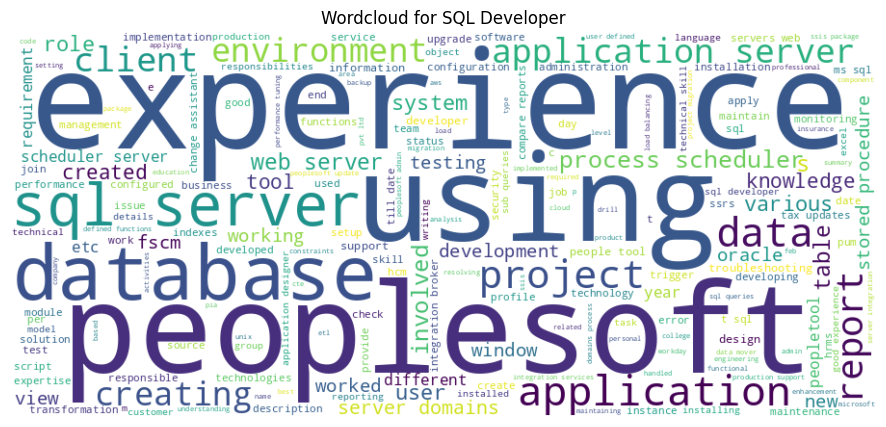

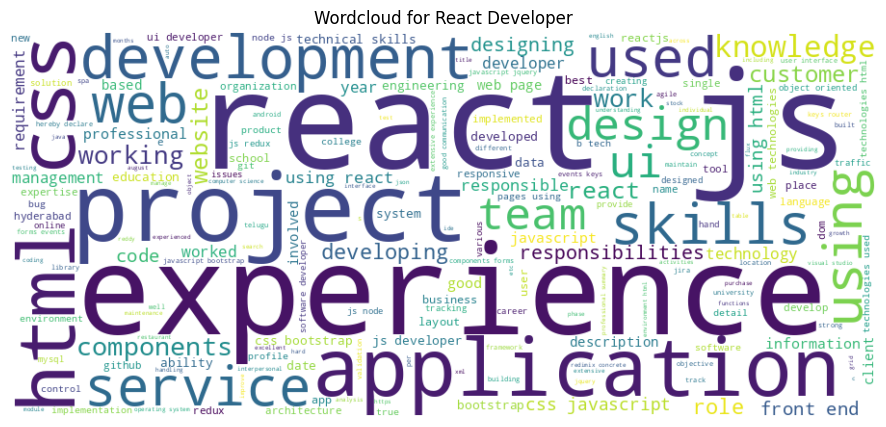

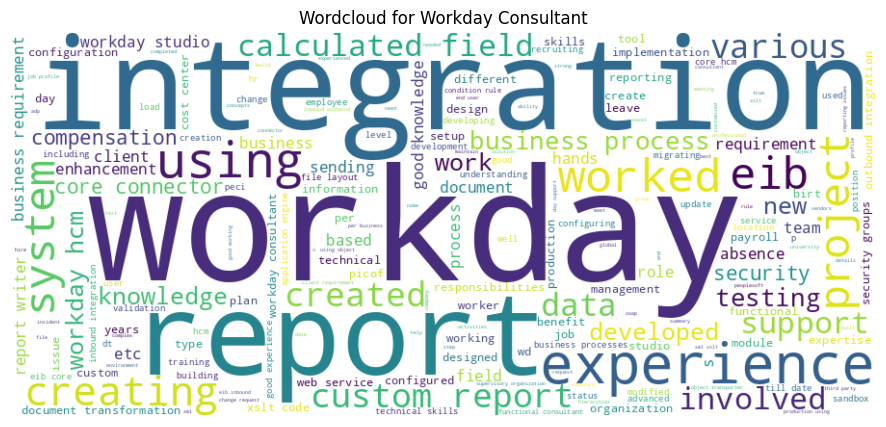

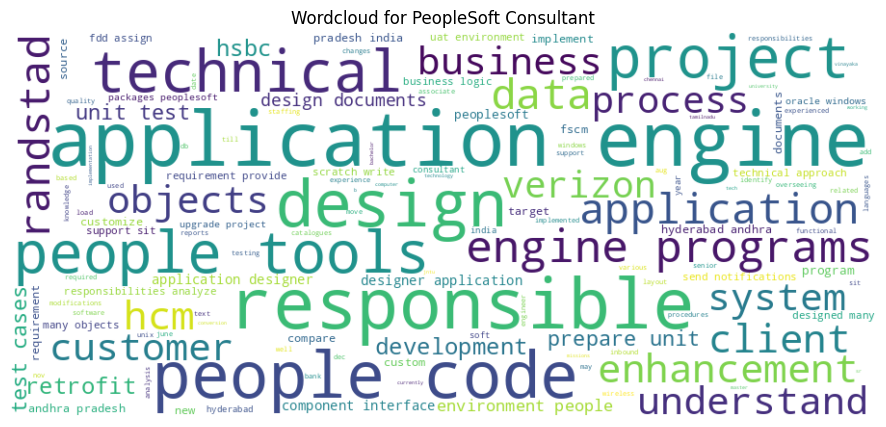

In [ ]:
# Wordclouds per category (visual)
for cat in df['label_auto'].value_counts().index:
    text = " ".join(df[df['label_auto']==cat]['text_alpha'])
    if len(text.strip())==0:
        continue
    wc = WordCloud(width=900, height=400, background_color='white').generate(text)
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Wordcloud for {cat}")
    plt.show()


In [ ]:
#Keyword counts useful for debugging labels
keywords = ["react","redux","javascript","sql","ssis","ssrs","peoplesoft","workday","eib","fscm","hcm","app engine","peoplecode"]
for kw in keywords:
    df[f"kw_{kw}"] = df['text_alpha'].apply(lambda x: x.split().count(kw))
kw_counts = {kw: int(df[f"kw_{kw}"].sum()) for kw in keywords}
print("Keyword totals:", kw_counts)


Keyword totals: {'react': 119, 'redux': 22, 'javascript': 47, 'sql': 178, 'ssis': 28, 'ssrs': 14, 'peoplesoft': 156, 'workday': 194, 'eib': 62, 'fscm': 36, 'hcm': 78, 'app engine': 0, 'peoplecode': 2}


In [ ]:
#Duplicate detection (exact cleaned text duplicates)
dups = df[df.duplicated('text_alpha', keep=False)].sort_values('label_auto')
print("Number of duplicate text entries:", len(dups))
if len(dups)>0:
    display(dups[['filename','label_auto','word_count']].head(20))


Number of duplicate text entries: 4


,filename,label_auto,word_count
27,React Dev_Krishna Kanth.docx,React Developer,530
28,React Dev_Krishna Kanth_Musquare Technologies....,React Developer,530
38,Reactjs Developer_M Lokesh Babu_Musquare Techn...,React Developer,305
39,Reactjs Developer_M Lokesh.docx,React Developer,305


In [ ]:
#Manual label corrections (OPTIONAL)

print(df['label_auto'].value_counts())


label_auto
SQL Developer            20
React Developer          20
Workday Consultant       11
PeopleSoft Consultant     2
Name: count, dtype: int64


In [ ]:
df['text_alpha']
df['label_auto']

,label_auto
0,SQL Developer
1,SQL Developer
2,SQL Developer
3,SQL Developer
4,Workday Consultant
5,Workday Consultant
6,Workday Consultant
7,React Developer
8,Workday Consultant
9,Workday Consultant


In [ ]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
df['label_auto']=LE.fit_transform(df['label_auto'])
df['label_auto']


,label_auto
0,2
1,2
2,2
3,2
4,3
5,3
6,3
7,1
8,3
9,3


In [ ]:
# splitting the Indepedent and Depedent Variable
from sklearn.model_selection import train_test_split
X=df['text_alpha']
Y=df['label_auto']

x_train,x_test,y_train,y_test=train_test_split(X,Y, test_size=0.2,random_state=42)

x_train


,text_alpha
8,jyoti verma years of experience in workday as ...
26,ramesh a workday hcm consultant professional s...
6,name ravali p curriculum vitae specialization ...
34,sri geethika prestige road number bandari layo...
4,name gopi krishna reddy professional summery w...
37,venkatalakshmi pedireddy software developer ex...
24,resume ramalakshmi k career objective professi...
44,shaik abdul sharuk years experience in wipro c...
33,pragnya pattnaik expertise having around years...
49,vinay kumar v workday functional consultant ex...


In [ ]:
#TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)

# quick sanity
print("TF-IDF shape:", X_train_tfidf.shape)

dic = {'tfidf': tfidf}


TF-IDF shape: (42, 5000)


In [ ]:
X_train_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Modeling Step

In [ ]:
# importing all the models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
all_models = pd.DataFrame(columns=['Model_name',"Accuracy"])
all_models

,Model_name,Accuracy


# Decision Tree Model

In [ ]:
# Intializing the Decision Tree model
model=DecisionTreeClassifier(criterion='entropy',max_depth=4)

In [ ]:
# providing the param grid values
import numpy as np
max_depth=np.arange(11)
criterion=['entropy','gini']
param_grid=dict(criterion=criterion,max_depth=max_depth)

In [ ]:
# intializing the gridsearchcv
import warnings
warnings.filterwarnings('ignore')
grid=GridSearchCV(model,param_grid=param_grid)
grid.fit(X_train_tfidf,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","DecisionTreeC..., max_depth=4)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': array([ 0, 1..., 8, 9, 10])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [ ]:
train_accuracy = grid.best_score_
print(grid.best_score_)
grid.best_params_

0.8166666666666668


{'criterion': 'entropy', 'max_depth': np.int64(2)}

In [ ]:
# considering the best estimator as the model
model=grid.best_estimator_
model.fit(X_train_tfidf,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(2)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [ ]:
# predicting the target values
y_predict=model.predict(X_test_tfidf)

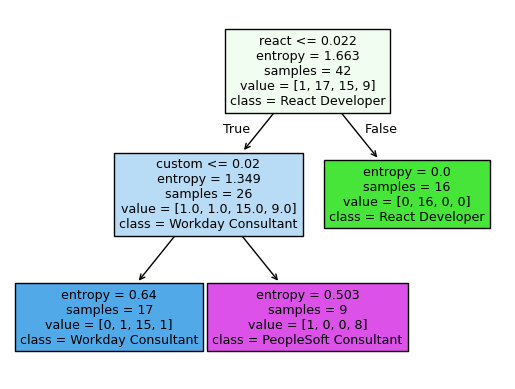

In [ ]:
# plotting the decision tree
fn=tfidf.get_feature_names_out()
cn=['SQL Developer','React Developer','Workday Consultant','PeopleSoft Consultant']
tree.plot_tree(model,feature_names=fn,class_names=cn,filled=True);

In [ ]:
import pandas as pd

# calculating the accuracy score,precision score,recall score and
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('Classification report')
print(classification_report(y_test,y_predict))

# Concatenate the new row to all_models
all_models.loc[0] = ['Decision Tree Classifier',accuracy_score(y_test,y_predict)]

Accuracy Score:0.7272727272727273
Classification report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.67      0.80         3
           2       0.80      0.80      0.80         5
           3       0.50      1.00      0.67         2

    accuracy                           0.73        11
   macro avg       0.57      0.62      0.57        11
weighted avg       0.73      0.73      0.70        11



In [ ]:
conufus_mat = confusion_matrix(y_test,y_predict)

Text(0.5, 23.52222222222222, 'Confusion Matrix')

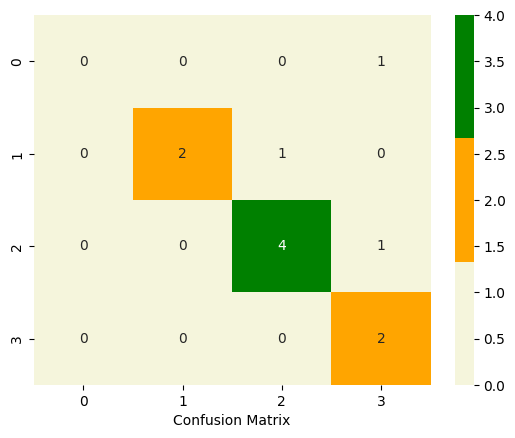

In [ ]:
import seaborn as sns
sns.heatmap(conufus_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

# Random Forest Model

In [ ]:
# intializng the randomforest model
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train_tfidf,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# predicting the target variables
y_predict=model.predict(X_test_tfidf)

In [ ]:
# calculating the accuracy score
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('classification report')
print(classification_report(y_test,y_predict))
all_models.loc[1] = ['Random Forest Classifier',accuracy_score(y_test,y_predict)]

Accuracy Score:0.9090909090909091
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       0.67      1.00      0.80         2

    accuracy                           0.91        11
   macro avg       0.92      0.95      0.92        11
weighted avg       0.94      0.91      0.91        11



In [ ]:
confusion_mat = confusion_matrix(y_test,y_predict)
print(confusion_mat)

[[1 0 0 0]
 [0 3 0 0]
 [0 0 4 1]
 [0 0 0 2]]


Text(0.5, 23.52222222222222, 'Confusion Matrix')

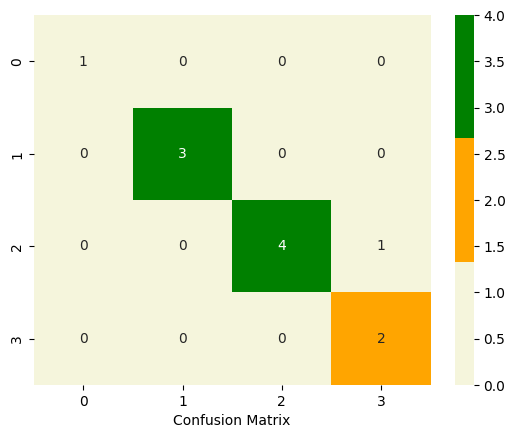

In [ ]:
import seaborn as sns
sns.heatmap(confusion_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

In [ ]:
dic['model']= model
with open('model3.pkl','wb') as file:
  pickle.dump(dic,file)

# SVC model

In [ ]:
# intializing the SVC
model=SVC(kernel='linear')

In [ ]:
# providing the param grid value
c=[1,10,20,30,50]
kernel=['linear','rbf']
gamma=[5,10,15,20,25,'scale']
param_grid=dict(C=c,kernel=kernel,gamma=gamma)


In [ ]:
# intializing the GridSearchCv
grid=GridSearchCV(model,param_grid=param_grid)
grid.fit(X_train_tfidf,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'gamma': [5, 10, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

In [ ]:
# Finding the best score and params
print(grid.best_score_)
print(grid.best_params_)

0.9555555555555555
{'C': 1, 'gamma': 5, 'kernel': 'linear'}


In [ ]:
# considering the best estimator as model
model=grid.best_estimator_
model.fit(X_train_tfidf,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# calculating the target variable
y_predict=model.predict(X_test_tfidf)

In [ ]:
# Calculating the accuracy score and classification report
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('Classification report')
print(classification_report(y_test,y_predict))
all_models.loc[2] = ['SVC', accuracy_score(y_test,y_predict)]

Accuracy Score:0.8181818181818182
Classification report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         3
           2       0.80      0.80      0.80         5
           3       0.67      1.00      0.80         2

    accuracy                           0.82        11
   macro avg       0.62      0.70      0.65        11
weighted avg       0.76      0.82      0.78        11



In [ ]:
confusion_mat = confusion_matrix(y_test,y_predict)
print(confusion_mat)

[[0 0 1 0]
 [0 3 0 0]
 [0 0 4 1]
 [0 0 0 2]]


Text(0.5, 23.52222222222222, 'Confusion Matrix')

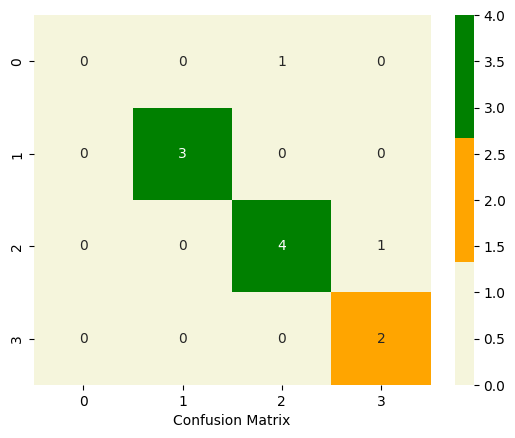

In [ ]:
import seaborn as sns
sns.heatmap(confusion_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

# KNeighbor Classifier Model

In [ ]:
# intializing the KNeighborClassifier
model=KNeighborsClassifier(n_neighbors=10)

In [ ]:
# provdeing the param grid values
n_neighbors=np.arange(11)
param_grid=dict(n_neighbors=n_neighbors)

In [ ]:
# intializing the gridsearchCv
grid=GridSearchCV(model,param_grid=param_grid)
grid.fit(X_train_tfidf,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla..._neighbors=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 0, 1..., 8, 9, 10])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [ ]:
# finding the best score and best paramas
print(grid.best_score_)
print(grid.best_params_)

0.9555555555555555
{'n_neighbors': np.int64(1)}


In [ ]:
# Considering the best estimator as model
model=grid.best_estimator_
model.fit(X_train_tfidf,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(1)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# Calculating the target variable
y_predict=model.predict(X_test_tfidf)

In [ ]:
# Calculating the accuracy score and classification report
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('Classification Report')
print(classification_report(y_test,y_predict))
all_models.loc[3] = ['KNeighbor Classifier', accuracy_score(y_test,y_predict)]

Accuracy Score:0.9090909090909091
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       0.67      1.00      0.80         2

    accuracy                           0.91        11
   macro avg       0.92      0.95      0.92        11
weighted avg       0.94      0.91      0.91        11



In [ ]:
confusion_mat = confusion_matrix(y_test,y_predict)
print(confusion_mat)

[[1 0 0 0]
 [0 3 0 0]
 [0 0 4 1]
 [0 0 0 2]]


Text(0.5, 23.52222222222222, 'Confusion Matrix')

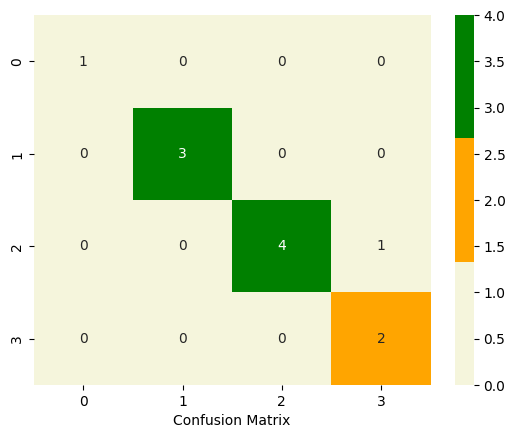

In [ ]:
import seaborn as sns
sns.heatmap(confusion_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

# Gradient Boosting Classifier model

In [ ]:
# Intializing the GradientBoostingClassifier
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1)
gbc.fit(X_train_tfidf,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
# predicting the target variable
y_predict=gbc.predict(X_test_tfidf)

In [ ]:
# Calculating the accuracy score and classification report
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('Classification report')
print(classification_report(y_test,y_predict))
all_models.loc[4] = ['Gradeint Boosting Classifier', accuracy_score(y_test,y_predict)]

Accuracy Score:0.8181818181818182
Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       0.80      0.80      0.80         5
           3       0.67      1.00      0.80         2

    accuracy                           0.82        11
   macro avg       0.87      0.87      0.85        11
weighted avg       0.85      0.82      0.82        11



In [ ]:
confusion_mat = confusion_matrix(y_test,y_predict)
print(confusion_mat)

[[1 0 0 0]
 [0 2 1 0]
 [0 0 4 1]
 [0 0 0 2]]


Text(0.5, 23.52222222222222, 'Confusion Matrix')

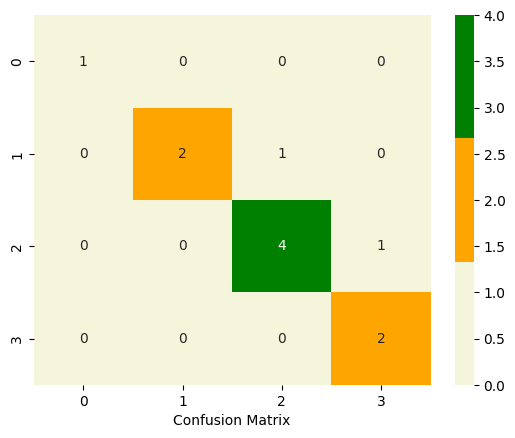

In [ ]:
import seaborn as sns
sns.heatmap(confusion_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

# XGBoost Classifier Model

In [ ]:
!pip install --upgrade scikit-learn xgboost

In [ ]:
# importing the xgboost algorithm
from xgboost import XGBClassifier

In [ ]:
# intializing the xgboost algorithm
xgb=XGBClassifier(n_estimators=100,learning_rate=0.1,colsample_bytree=0.8,max_depth=7)
xgb.fit(X_train_tfidf,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
# predicting the target values for the test data
y_predict=xgb.predict(X_test_tfidf)

In [ ]:
# Calculating the accuracy score
print(f'Accuracy Score:{accuracy_score(y_test,y_predict)}')
print('Classification report')
print(classification_report(y_test,y_predict))
all_models.loc[5] = ["XGBoosting Classifier", accuracy_score(y_test,y_predict)]

Accuracy Score:0.8181818181818182
Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       0.80      0.80      0.80         5
           3       0.67      1.00      0.80         2

    accuracy                           0.82        11
   macro avg       0.87      0.87      0.85        11
weighted avg       0.85      0.82      0.82        11



In [ ]:
confusion_mat = confusion_matrix(y_test,y_predict)
print(confusion_mat)

[[1 0 0 0]
 [0 2 1 0]
 [0 0 4 1]
 [0 0 0 2]]


Text(0.5, 23.52222222222222, 'Confusion Matrix')

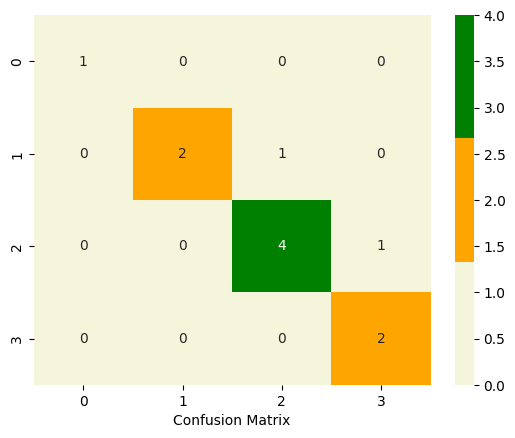

In [ ]:
import seaborn as sns
sns.heatmap(confusion_mat,cmap=['Beige','orange','green'],annot=True);
plt.xlabel('Confusion Matrix')

In [ ]:

!pip install keras

In [ ]:
# Artificial Neural Network model
from keras.models import Sequential
from keras.layers import Dense,Dropout

In [ ]:
model = Sequential()
model.add(Dense(12,input_dim =5000, activation = 'relu'))
model.add(Dense(7,activation = 'relu'))
model.add(Dense(4, activation='softmax'))

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# from tensorflow.keras.utils import to_categorical

# y_train_one_hot = to_categorical(y_train)
# y_test_one_hot = to_categorical(y_test)

model.fit(X_train_tfidf, y_train, batch_size=5, validation_split=0.20, epochs=200)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.2949 - loss: 1.3816 - val_accuracy: 0.4444 - val_loss: 1.3715
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5325 - loss: 1.3396 - val_accuracy: 0.4444 - val_loss: 1.3532
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6142 - loss: 1.3013 - val_accuracy: 0.4444 - val_loss: 1.3315
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8241 - loss: 1.2082 - val_accuracy: 0.4444 - val_loss: 1.3095
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7768 - loss: 1.1777 - val_accuracy: 0.5556 - val_loss: 1.2863
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8472 - loss: 1.1106 - val_accuracy: 0.5556 - val_loss: 1.2599
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9562 - loss: 1.0312 - val_accuracy: 0.6667 - val_loss: 1.2266
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9687 - loss: 0.9390 - val_accuracy: 0.7778 - val_loss:

In [ ]:
model.predict(X_test_tfidf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


array([[1.6730009e-03, 2.4143396e-02, 7.2701383e-01, 2.4716984e-01],
       [1.0263592e-03, 4.1135541e-01, 5.4886043e-01, 3.8757648e-02],
       [7.8163038e-07, 7.5065287e-07, 2.3236112e-03, 9.9767488e-01],
       [1.5436897e-06, 4.8802968e-04, 9.9819833e-01, 1.3121701e-03],
       [1.1508211e-03, 8.9260322e-01, 8.9597024e-02, 1.6649032e-02],
       [7.9324254e-06, 9.1838110e-06, 6.0982732e-03, 9.9388462e-01],
       [9.9287417e-06, 1.7203183e-03, 9.9515176e-01, 3.1179951e-03],
       [6.5090137e-07, 2.6038635e-04, 9.9903303e-01, 7.0582516e-04],
       [1.0079490e-05, 9.7434540e-06, 8.0916677e-03, 9.9188846e-01],
       [2.1831626e-03, 5.3674746e-01, 3.6606914e-01, 9.5000260e-02],
       [2.5909771e-05, 2.8617019e-03, 9.9126244e-01, 5.8499039e-03]],
      dtype=float32)

In [ ]:
model.evaluate(X_test_tfidf,y_test)
model.evaluate(X_train_tfidf,y_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7273 - loss: 1.1690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9841 - loss: 0.1087


[0.16192743182182312, 0.976190447807312]

In [ ]:
# all models in a data frame with accuracy and model name
all_models

,Model_name,Accuracy
0,Decision Tree Classifier,0.727273
1,Random Forest Classifier,0.909091
2,SVC,0.818182
3,KNeighbor Classifier,0.909091
4,Gradeint Boosting Classifier,0.818182
5,XGBoosting Classifier,0.818182
